In [104]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from data import SwaptionDataset
from torch.utils.data import DataLoader, Subset
from perceval import *
from merlin import QuantumLayer


In [105]:
dataset = SwaptionDataset()
n = len(dataset)
train_ds = Subset(dataset, range(0, 460))
val_ds  = Subset(dataset, range(460, n))

device = "cuda" if torch.cuda.is_available() else "cpu"

loader = DataLoader(train_ds, batch_size=64, shuffle=True) # Shuffle is usually better for training
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

In [106]:
# LSTM → Classical compression → Quantum circuit → Regressor
class SwaptionPredictor(nn.Module):
    def __init__(self):
        super(SwaptionPredictor, self).__init__()

        self.lstm = nn.LSTM(
            input_size=225,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.feature_reduction = nn.Linear(64, 8)

        n_modes   = 8
        n_photons = 2   

        input_params = [P(f"x{i}") for i in range(n_modes)]

        circuit = Circuit(n_modes)

        interferometer1 = GenericInterferometer(
            n_modes,
            catalog["mzi phase first"].generate
        )
        circuit.add(0, interferometer1)

        for i in range(n_modes):
            circuit.add(i, PS(input_params[i]))

        interferometer2 = GenericInterferometer(
            n_modes,
            catalog["mzi phase first"].generate,
        )
        for p in interferometer2.get_parameters():
            p.name = "layer2_" + p.name

        circuit.add(0, interferometer2)

        all_params  = circuit.get_parameters()
        train_params = [p.name for p in all_params if not p.name.startswith("x")]

        # Build input state: n_photons ones followed by zeros
        photon_state = [1] * n_photons + [0] * (n_modes - n_photons)

        self.quantum_layer = QuantumLayer(
            circuit=circuit,
            input_state=BasicState(photon_state),
            input_parameters=[f"x{i}" for i in range(n_modes)],
            trainable_parameters=train_params,
            computation_space="Fock"
        )

        print(f"n_photons={n_photons}  →  Quantum output size: {self.quantum_layer.output_size}")

        self.regressor = nn.Linear(self.quantum_layer.output_size, 224)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        x = hn.squeeze(0)
        x = self.feature_reduction(x)
        x = torch.sigmoid(x) * torch.pi
        x = self.quantum_layer(x)
        x = self.regressor(x)
        return x

In [107]:
# %%
# 3. INITIALIZATION
model = SwaptionPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

n_photons=2  →  Quantum output size: 36


In [108]:
# 4. TRAINING LOOP
num_epochs = 150
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in loader:
        # Safety: Ensure data is Float32 (Linear/LSTM layers expect this)
        inputs, targets = inputs.float(), targets.float()
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # avg_loss = running_loss / len(loader)
    loss_history.append(running_loss)

    if (epoch + 1) % 5 == 0: # Print every 5 epochs to keep it clean
        print(f"Epoch [{epoch+1}/{num_epochs}] | MSE Loss: {running_loss:.8f}")

print("Training Complete!")

# Switch to evaluation mode
model.eval()

MATURITIES = [0.083, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

def validation(tenor, maturity):
    complete_loader = DataLoader(dataset, batch_size=256, shuffle=False)

    model.eval()

    tenor_idx = dataset.tenors.index(tenor)
    maturity_idx = MATURITIES.index(round(maturity, 3))
    col = maturity_idx * len(dataset.tenors) + tenor_idx

    real_prices = []
    model_prices = []

    with torch.no_grad():
        for X, y in complete_loader:

            X = X.to(device)
            y = y.to(device)

            preds = model(X)

            real_prices.extend(y[:, col].cpu().numpy())
            model_prices.extend(preds[:, col].cpu().numpy())

    return model_prices, real_prices

Epoch [5/150] | MSE Loss: 0.33471561
Epoch [10/150] | MSE Loss: 0.17319205
Epoch [15/150] | MSE Loss: 0.08122302
Epoch [20/150] | MSE Loss: 0.03467230
Epoch [25/150] | MSE Loss: 0.01588008
Epoch [30/150] | MSE Loss: 0.00733822
Epoch [35/150] | MSE Loss: 0.00492250
Epoch [40/150] | MSE Loss: 0.00369791
Epoch [45/150] | MSE Loss: 0.00297172
Epoch [50/150] | MSE Loss: 0.00237547
Epoch [55/150] | MSE Loss: 0.00197058
Epoch [60/150] | MSE Loss: 0.00170661
Epoch [65/150] | MSE Loss: 0.00156673
Epoch [70/150] | MSE Loss: 0.00148508
Epoch [75/150] | MSE Loss: 0.00138391
Epoch [80/150] | MSE Loss: 0.00124328
Epoch [85/150] | MSE Loss: 0.00122776
Epoch [90/150] | MSE Loss: 0.00119448
Epoch [95/150] | MSE Loss: 0.00118784
Epoch [100/150] | MSE Loss: 0.00108548
Epoch [105/150] | MSE Loss: 0.00108631
Epoch [110/150] | MSE Loss: 0.00103912
Epoch [115/150] | MSE Loss: 0.00098534
Epoch [120/150] | MSE Loss: 0.00096028
Epoch [125/150] | MSE Loss: 0.00101555
Epoch [130/150] | MSE Loss: 0.00100368
Epoch 

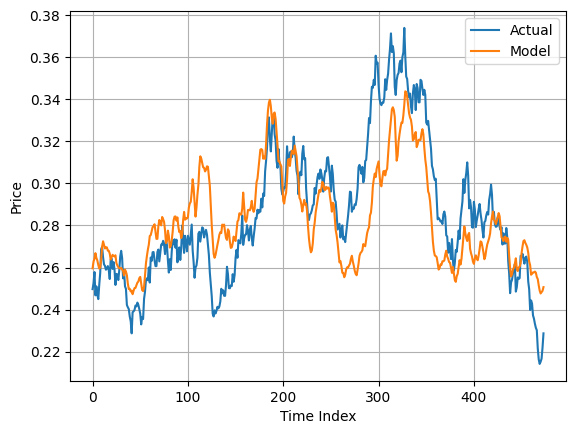

In [109]:
model_prices, real_prices = validation(tenor=1, maturity=3)

plt.figure()
plt.title("")
plt.plot(real_prices, label="Actual")
plt.plot(model_prices, label="Model")
plt.grid()
plt.xlabel("Time Index")
plt.ylabel("Price")
plt.legend()
plt.show()

# Get one batch of real data
val_inputs, val_targets = next(iter(val_loader))
train_inputs, train_targets = next(iter(loader))

# Get the model's guess
with torch.no_grad():
    val_predictions = model(val_inputs.float())
    train_predictions = model(train_inputs.float())

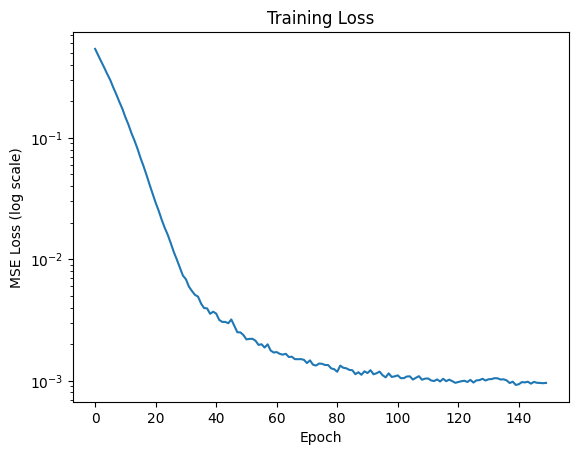

In [110]:
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Training Loss")
plt.show()

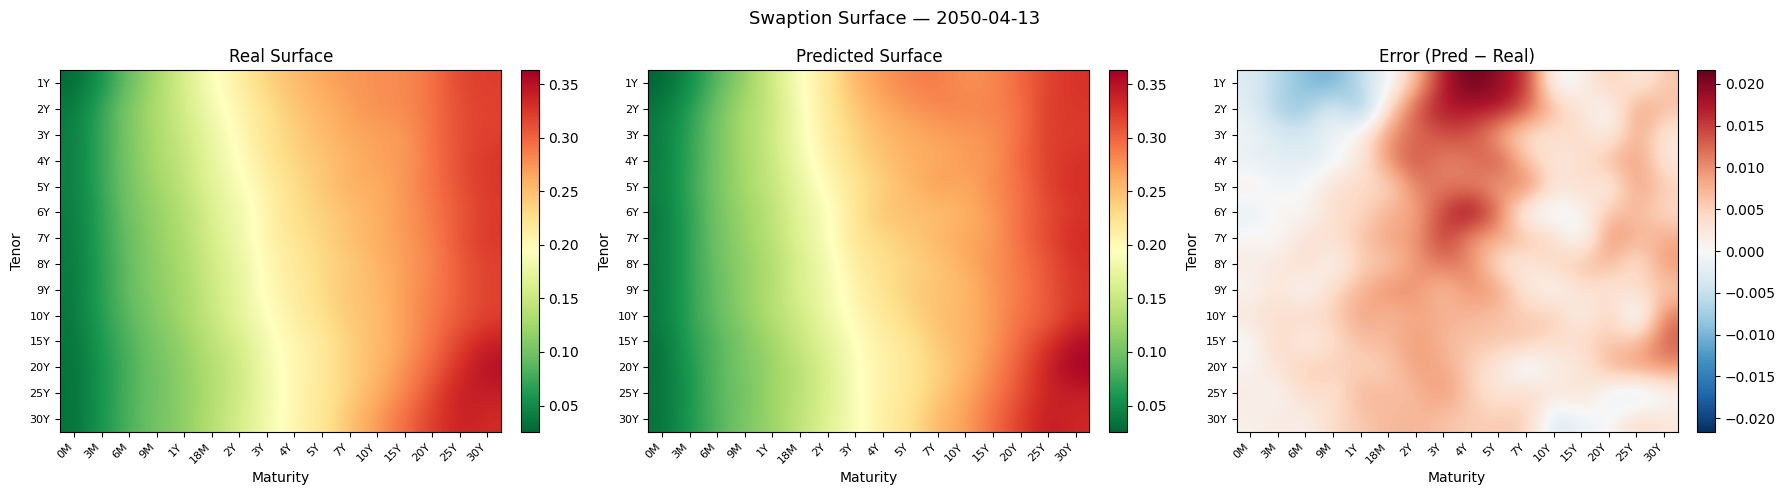

MAE  : 0.005862
Max |error| : 0.021622  at Tenor=1Y, Maturity=4Y


In [111]:
import numpy as np

TENORS_LIST    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30]
MATURITIES_LIST = [0.083, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

MAT_LABELS = ["0M","3M","6M","9M","1Y","18M","2Y","3Y","4Y","5Y","7Y","10Y","15Y","20Y","25Y","30Y"]
TEN_LABELS = [f"{t}Y" for t in TENORS_LIST]

def plot_surface_comparison(model, dataset, sample_idx=-1):
    """Compare real vs predicted swaption surface for one sample day."""
    model.eval()

    idx = sample_idx if sample_idx >= 0 else len(dataset) + sample_idx
    x, y_real = dataset[idx]

    with torch.no_grad():
        y_pred = model(x.float().unsqueeze(0)).squeeze(0).numpy()
    y_real = y_real.numpy()

    # Reshape [224] → [14 tenors, 16 maturities]  (Tenor on Y-axis, Maturity on X-axis)
    # Column ordering in dataset: maturity-major → reshape to [16 mat, 14 ten], then transpose
    real  = y_real.reshape(len(MATURITIES_LIST), len(TENORS_LIST)).T   # [14, 16]
    pred  = y_pred.reshape(len(MATURITIES_LIST), len(TENORS_LIST)).T
    error = pred - real

    vmin, vmax = min(real.min(), pred.min()), max(real.max(), pred.max())
    absmax = np.abs(error).max()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    panels = [
        (real,  "Real Surface",       "RdYlGn_r", dict(vmin=vmin, vmax=vmax)),
        (pred,  "Predicted Surface",  "RdYlGn_r", dict(vmin=vmin, vmax=vmax)),
        (error, "Error (Pred − Real)","RdBu_r",   dict(vmin=-absmax, vmax=absmax)),
    ]

    for ax, (data, title, cmap, kwargs) in zip(axes, panels):
        im = ax.imshow(data, aspect='auto', cmap=cmap, origin='upper',
                       interpolation='bicubic', **kwargs)
        ax.set_xticks(range(len(MATURITIES_LIST)))
        ax.set_xticklabels(MAT_LABELS, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(TENORS_LIST)))
        ax.set_yticklabels(TEN_LABELS, fontsize=8)
        ax.set_xlabel("Maturity")
        ax.set_ylabel("Tenor")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    date = dataset.dates.iloc[idx + dataset.lookback].date()
    plt.suptitle(f"Swaption Surface — {date}", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/surface_comparison.png", bbox_inches='tight')
    plt.show()

    mae = np.abs(error).mean()
    print(f"MAE  : {mae:.6f}")
    worst = np.unravel_index(np.abs(error).argmax(), error.shape)
    print(f"Max |error| : {np.abs(error).max():.6f}  at Tenor={TEN_LABELS[worst[0]]}, Maturity={MAT_LABELS[worst[1]]}")


# --- Plot the last validation day ---
plot_surface_comparison(model, dataset, sample_idx=50)

## Validation Analysis
We verify that the model generalizes well by comparing metrics on train, validation and the persistence baseline (predicting yesterday's price as tomorrow's price).

In [112]:
import numpy as np
from torch.utils.data import DataLoader

# ── Helpers ──────────────────────────────────────────────────────────────────

def get_predictions(model, subset):
    model.eval()
    all_real, all_pred = [], []
    dl = DataLoader(subset, batch_size=64, shuffle=False)
    with torch.no_grad():
        for x, y in dl:
            all_real.append(y.numpy())
            all_pred.append(model(x.float()).numpy())
    return np.concatenate(all_real), np.concatenate(all_pred)

def get_persistence(subset):
    """Baseline: predict last observed price (x[:, -1, 1:])."""
    all_real, all_pers = [], []
    dl = DataLoader(subset, batch_size=64, shuffle=False)
    for x, y in dl:
        all_real.append(y.numpy())
        all_pers.append(x[:, -1, 1:].numpy())   # last day's 224 prices
    return np.concatenate(all_real), np.concatenate(all_pers)

def print_metrics(real, pred, name):
    mae  = np.abs(real - pred).mean()
    rmse = np.sqrt(((real - pred) ** 2).mean())
    r2   = 1 - np.sum((real - pred) ** 2) / np.sum((real - real.mean()) ** 2)
    mape = (np.abs((real - pred) / (real + 1e-8))).mean() * 100
    print(f"  {name:<28s}  MAE={mae:.5f}  RMSE={rmse:.5f}  R²={r2:.4f}  MAPE={mape:.2f}%")

# ── Evaluate ──────────────────────────────────────────────────────────────────

real_tr,  pred_tr  = get_predictions(model, train_ds)
real_val, pred_val = get_predictions(model, val_ds)
_,        pers_val = get_persistence(val_ds)

print("=" * 75)
print_metrics(real_tr,  pred_tr,  "Model — Train (460 samples)")
print_metrics(real_val, pred_val, "Model — Validation (14 days)")


  Model — Train (460 samples)   MAE=0.00787  RMSE=0.01099  R²=0.9879  MAPE=3.94%
  Model — Validation (14 days)  MAE=0.00968  RMSE=0.01209  R²=0.9842  MAPE=6.48%


### Error Maps — last 14 validation days (2 weeks)
Each panel shows the error (Predicted − Real) for one day. Blue = underestimation, Red = overestimation. If the model generalizes well, errors should be small and show no systematic pattern.

/tmp/ipykernel_24396/801811775.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


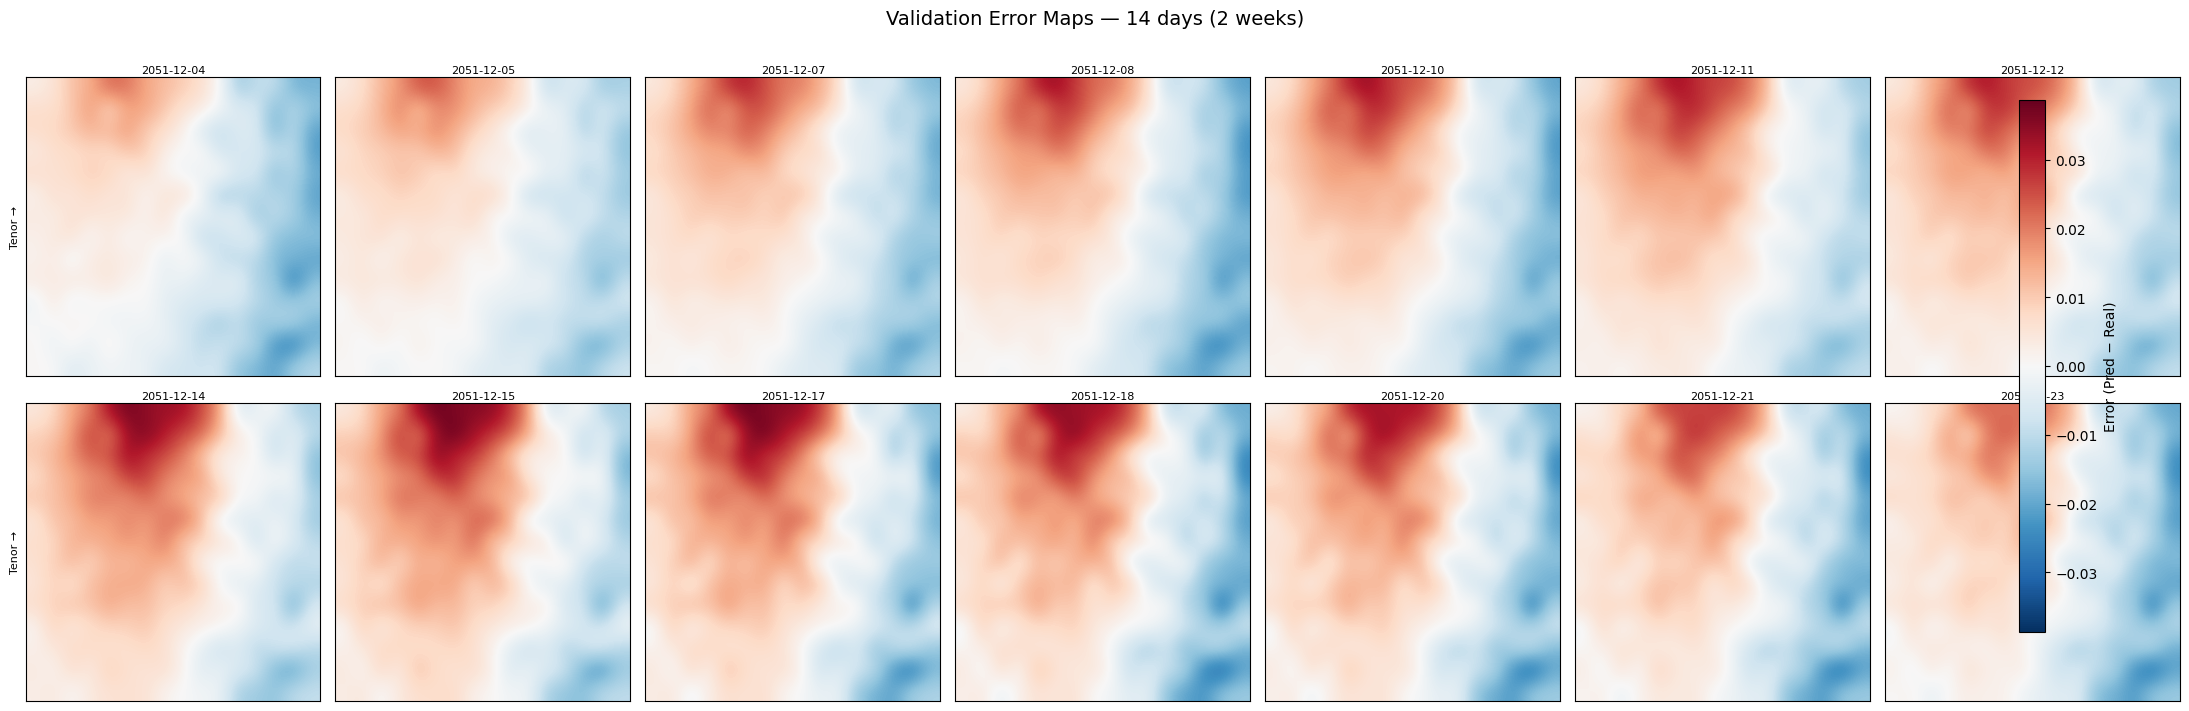

Global absmax error: 0.03866


In [113]:
import numpy as np

N_MAT = len(MATURITIES_LIST)
N_TEN = len(TENORS_LIST)

# ── Collect all 14 validation surfaces ───────────────────────────────────────
val_start = 460
n_val     = len(val_ds)   # 14

val_reals, val_preds, val_dates = [], [], []
model.eval()
with torch.no_grad():
    for i in range(val_start, val_start + n_val):
        x, y = dataset[i]
        p = model(x.float().unsqueeze(0)).squeeze(0).numpy()
        val_reals.append(y.numpy().reshape(N_MAT, N_TEN).T)   # [14ten, 16mat]
        val_preds.append(p.reshape(N_MAT, N_TEN).T)
        val_dates.append(dataset.dates.iloc[i + dataset.lookback].date())

val_reals = np.array(val_reals)   # [14, 14, 16]
val_preds = np.array(val_preds)

# ── 2×7 grid of error maps ───────────────────────────────────────────────────
absmax = np.abs(val_preds - val_reals).max()

fig, axes = plt.subplots(2, 7, figsize=(22, 7))
fig.patch.set_facecolor("white")

for k, ax in enumerate(axes.flatten()):
    err = val_preds[k] - val_reals[k]
    im  = ax.imshow(err, aspect="auto", cmap="RdBu_r", origin="upper",
                    vmin=-absmax, vmax=absmax, interpolation="bicubic")
    ax.set_title(str(val_dates[k]), fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])

# Shared colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.12, 0.012, 0.76])
cb = fig.colorbar(im, cax=cbar_ax)
cb.set_label("Error (Pred − Real)", fontsize=10)

fig.suptitle("Validation Error Maps — 14 days (2 weeks)", fontsize=14, y=1.01)

axes[0][0].set_ylabel("Tenor →", fontsize=8)
axes[1][0].set_ylabel("Tenor →", fontsize=8)

plt.tight_layout()
plt.savefig("figures/val_error_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Global absmax error: {absmax:.5f}")

### Predicted vs Real Surface 
Full comparison for the first and last validation day.

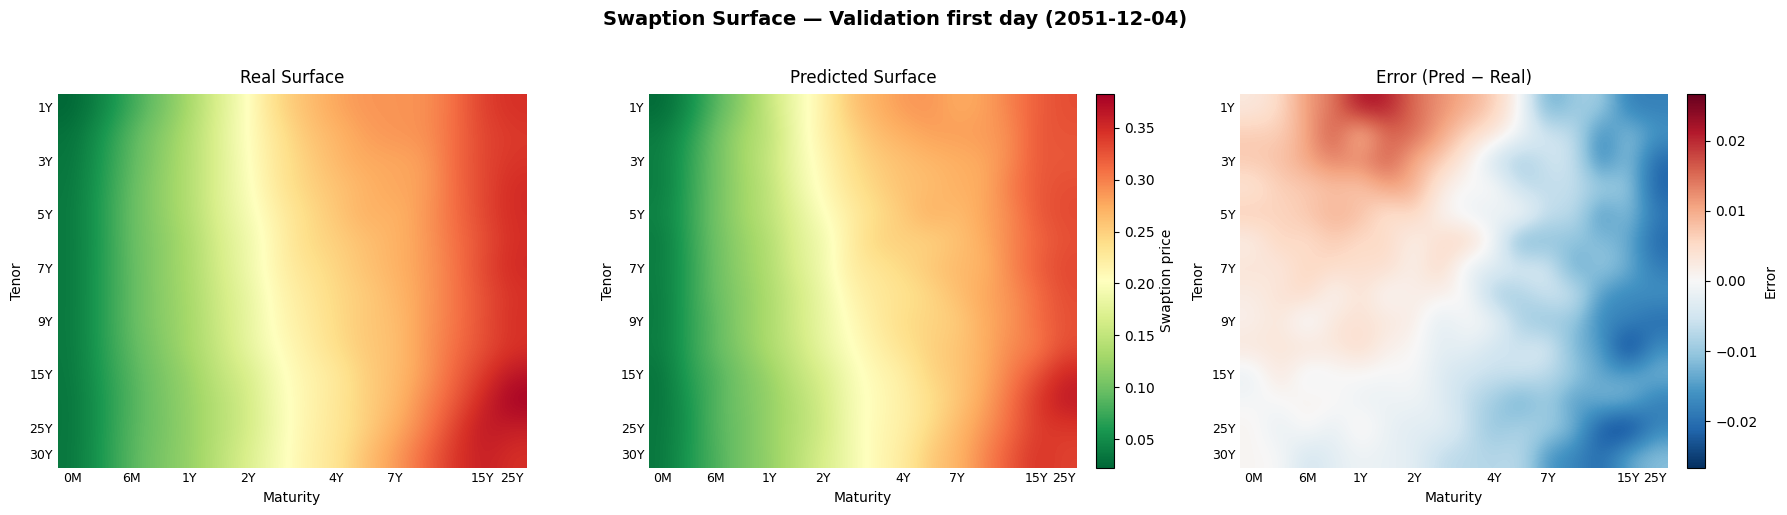

[2051-12-04]  MAE=0.007687  Max|err|=0.026615


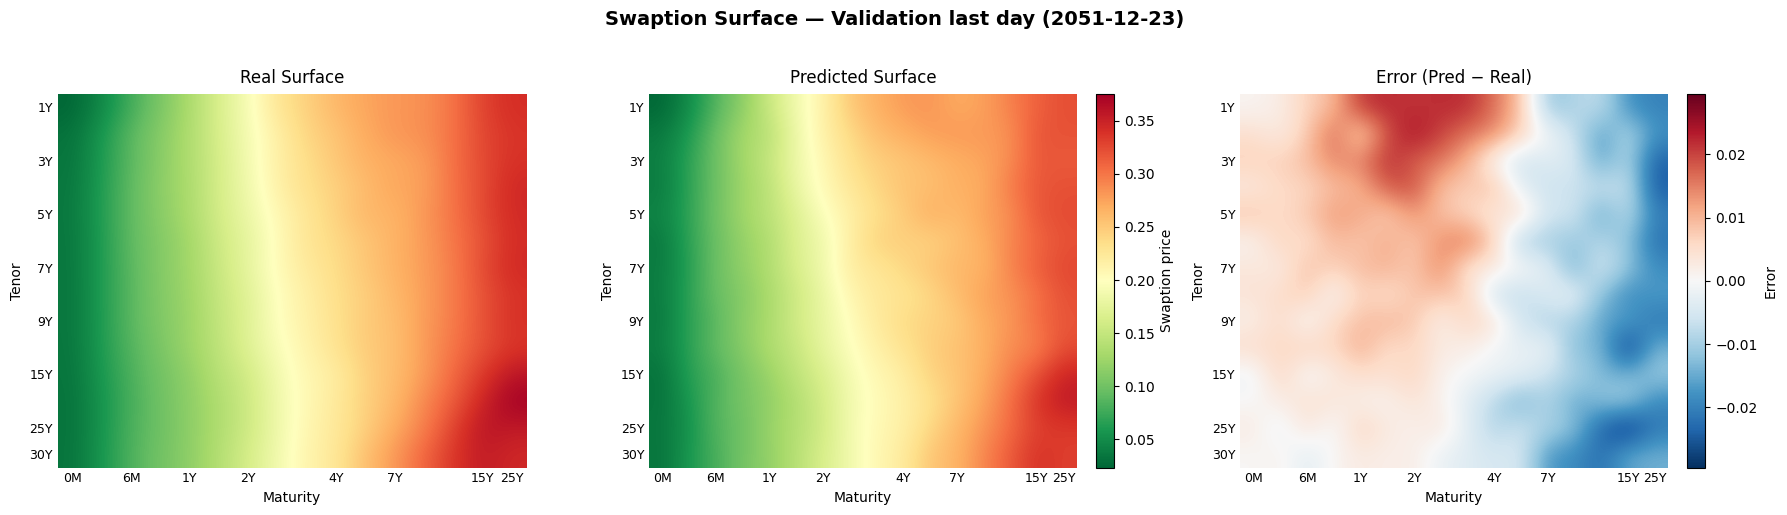

[2051-12-23]  MAE=0.008853  Max|err|=0.029504


In [114]:
def plot_surface_slide(data, title, ax, vmin, vmax, cmap="RdYlGn_r"):
    """Single panel in slide-5 style: smooth gradient, clean axes."""
    im = ax.imshow(data, aspect="auto", cmap=cmap, origin="upper",
                   vmin=vmin, vmax=vmax, interpolation="bicubic")
    # Sparse tick labels to match the slide style
    x_ticks = [0, 2, 4, 6, 9, 11, 14, 15]        # 0M 6M 1Y 2Y 4Y 7Y 15Y 25Y
    y_ticks = [0, 2, 4, 6, 8, 10, 12, 13]         # 1Y 3Y 5Y 7Y 9Y 15Y 25Y 30Y
    x_labels = ["0M","6M","1Y","2Y","4Y","7Y","15Y","25Y"]
    y_labels = ["1Y","3Y","5Y","7Y","9Y","15Y","25Y","30Y"]
    ax.set_xticks(x_ticks); ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel("Maturity", fontsize=10)
    ax.set_ylabel("Tenor",    fontsize=10)
    ax.set_title(title, fontsize=12, pad=8)
    ax.tick_params(length=0)           # no tick marks, just labels (slide style)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return im


# ── Plot first and last validation day ───────────────────────────────────────
for day_idx, label in [(0, "first"), (n_val - 1, "last")]:
    real  = val_reals[day_idx]
    pred  = val_preds[day_idx]
    error = pred - real
    date  = val_dates[day_idx]

    vmin_s = min(real.min(), pred.min())
    vmax_s = max(real.max(), pred.max())
    absmax_s = np.abs(error).max()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor("white")

    im1 = plot_surface_slide(real,  "Real Surface",       axes[0], vmin_s, vmax_s)
    im2 = plot_surface_slide(pred,  "Predicted Surface",  axes[1], vmin_s, vmax_s)
    im3 = plot_surface_slide(error, "Error (Pred − Real)",axes[2], -absmax_s, absmax_s, cmap="RdBu_r")

    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="Swaption price")
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, label="Error")

    fig.suptitle(f"Swaption Surface — Validation {label} day ({date})",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"figures/val_surface_{label}.png", dpi=130, bbox_inches="tight")
    plt.show()

    mae = np.abs(error).mean()
    print(f"[{date}]  MAE={mae:.6f}  Max|err|={np.abs(error).max():.6f}")

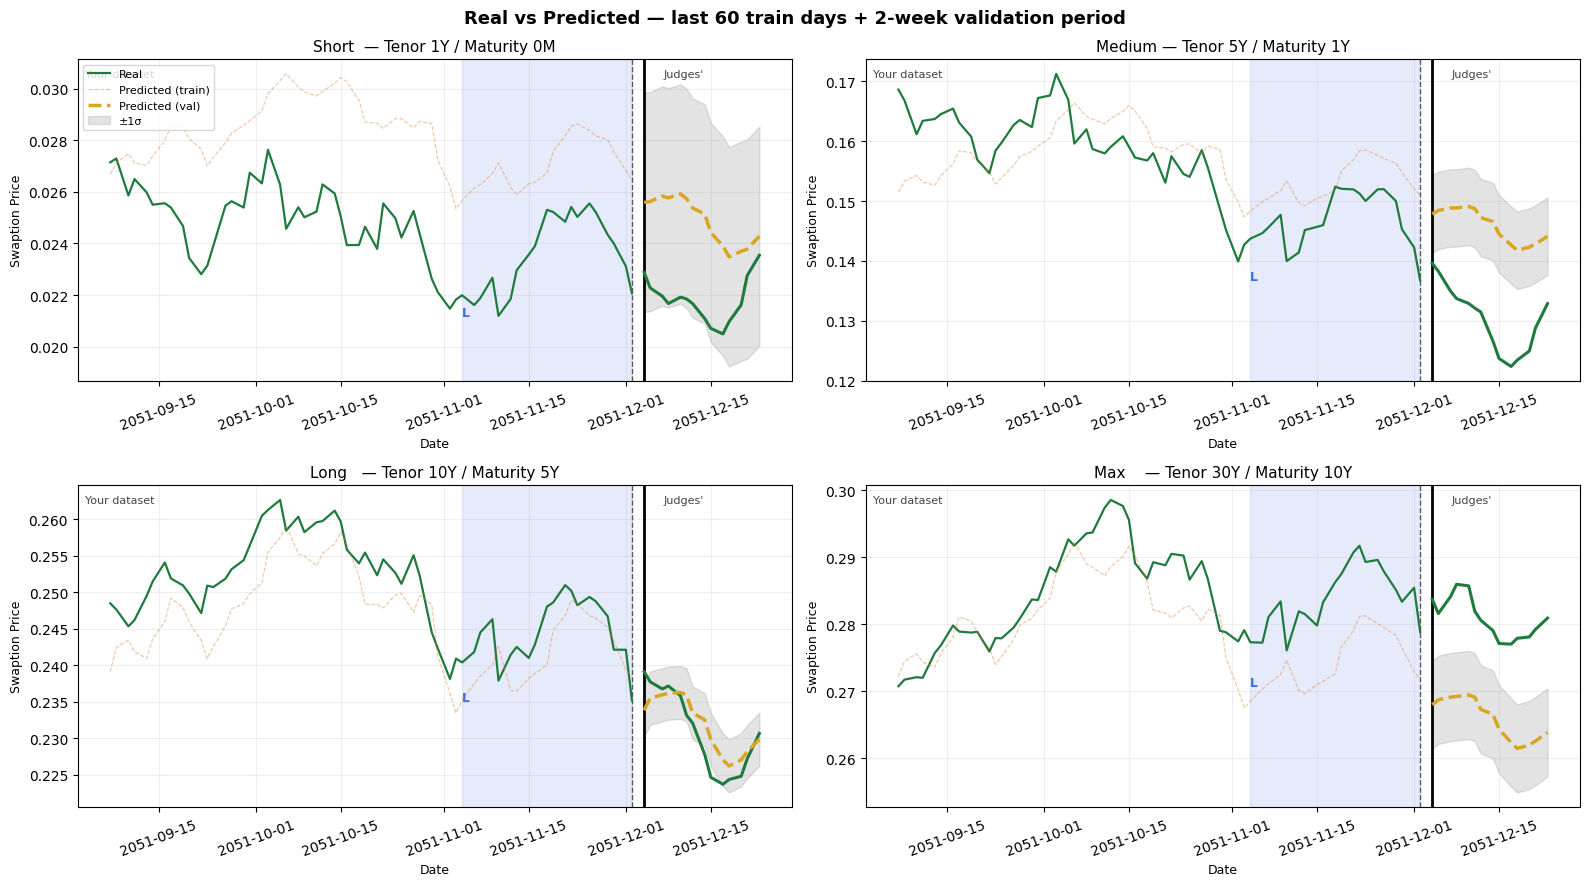

In [115]:
from data.data import TENORS, MATURITIES

TENORS_LIST     = TENORS
MATURITIES_LIST = MATURITIES
N_TEN, N_MAT    = len(TENORS_LIST), len(MATURITIES_LIST)
TRAIN_SPLIT     = 460
CONTEXT_DAYS    = 60   # ← how many training days to show on the left (change freely)

# Pre-compute predictions for ALL samples (train + val) once
all_reals, all_preds, pred_dates = [], [], []
model.eval()
with torch.no_grad():
    for i in range(len(dataset)):
        x, y = dataset[i]
        p = model(x.float().unsqueeze(0)).squeeze(0).numpy()
        all_reals.append(y.numpy())
        all_preds.append(p)
        pred_dates.append(dataset.dates.iloc[i + dataset.lookback])

all_reals  = np.array(all_reals)   # [474, 224]
all_preds  = np.array(all_preds)
split_date = pred_dates[TRAIN_SPLIT]

# Window to display: last CONTEXT_DAYS of train + all val
show_start = TRAIN_SPLIT - CONTEXT_DAYS

selected = [
    (1,  0.0833333333333333, "Short  — Tenor 1Y / Maturity 0M"),
    (5,  1.0,               "Medium — Tenor 5Y / Maturity 1Y"),
    (10, 5.0,               "Long   — Tenor 10Y / Maturity 5Y"),
    (30, 10.0,              "Max    — Tenor 30Y / Maturity 10Y"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor("white")

for ax, (tenor, maturity, label) in zip(axes.flatten(), selected):
    t_idx = TENORS_LIST.index(tenor)
    m_idx = min(range(N_MAT), key=lambda i: abs(MATURITIES_LIST[i] - maturity))
    col   = m_idx * N_TEN + t_idx

    real = all_reals[:, col]
    pred = all_preds[:, col]

    train_std = np.abs(pred[:TRAIN_SPLIT] - real[:TRAIN_SPLIT]).std()

    # ── Blue shading: lookback window at the split boundary ──
    lb_start = TRAIN_SPLIT - dataset.lookback
    ax.axvspan(pred_dates[lb_start], pred_dates[TRAIN_SPLIT - 1],
               alpha=0.13, color="royalblue", zorder=1)
    ax.annotate("L", xy=(pred_dates[lb_start], real[show_start:TRAIN_SPLIT].min()),
                fontsize=9, color="royalblue", fontweight="bold")

    # ── Dashed vertical: last training prediction point ──
    ax.axvline(pred_dates[TRAIN_SPLIT - 1], color="black", linewidth=1,
               linestyle="--", alpha=0.6)

    # ── Solid vertical: train / val boundary ──
    ax.axvline(split_date, color="black", linewidth=2)

    # ── Real price — only CONTEXT_DAYS before split + all val ──
    ax.plot(pred_dates[show_start:TRAIN_SPLIT], real[show_start:TRAIN_SPLIT],
            color="#1f7a3e", linewidth=1.6, label="Real")
    ax.plot(pred_dates[TRAIN_SPLIT:], real[TRAIN_SPLIT:],
            color="#1f7a3e", linewidth=2.2)

    # ── Predicted — context train (faint) ──
    ax.plot(pred_dates[show_start:TRAIN_SPLIT], pred[show_start:TRAIN_SPLIT],
            color="#e07b2a", linewidth=0.8, linestyle="--", alpha=0.45,
            label="Predicted (train)")

    # ── Predicted — val (bold dashed) ──
    ax.plot(pred_dates[TRAIN_SPLIT:], pred[TRAIN_SPLIT:],
            color="goldenrod", linewidth=2.5, linestyle="--",
            label="Predicted (val)")

    # ── Uncertainty band on val ──
    ax.fill_between(pred_dates[TRAIN_SPLIT:],
                    pred[TRAIN_SPLIT:] - train_std,
                    pred[TRAIN_SPLIT:] + train_std,
                    alpha=0.22, color="gray", label="±1σ")

    ax.text(0.01, 0.97, "Your dataset", transform=ax.transAxes,
            fontsize=8, va="top", color="#444444")
    ax.text(0.82, 0.97, "Judges'", transform=ax.transAxes,
            fontsize=8, va="top", color="#444444")

    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Swaption Price", fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="x", rotation=20)

axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Real vs Predicted — last 60 train days + 2-week validation period",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/timeseries_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## Save Model

In [116]:
torch.save(model.state_dict(), "model.pth")
print("Model saved to model.pth")

Model saved to model.pth
